# 01 — Geo source profiling: communes + RPG (Tarn-et-Garonne, dept 82)

**Purpose:** Before building the pipeline, verify what the actual API returns.

- **Shape:** Which fields are returned, with what data types and geometry types?
- **Volume:** How many parcels are contained in a single tile, and what is the estimated volume
            when scaling to the entire department? 
- **Quality:** Invalid geometries, missing values, and discrepancies between declared and calculated areas.

Scope: All communes (to generate the departmental boundary), 3 sample communes, and 1 RPG 5km tile.
This notebook is for exploratory analysis. Production code belongs in `src/hive_platform/ingest/`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from shapely.geometry import box, mapping
from urllib3.util.retry import Retry

DEPT_CODE = "82"
RPG_YEAR = 2024
CRS_WGS84 = "EPSG:4326"
CRS_L93 = "EPSG:2154"
GEO_API = "https://geo.api.gouv.fr"
RPG_API = "https://apicarto.ign.fr/api/rpg/v2"
TILE_SIZE_M = 5000
SAMPLE_COMMUNE = "Moissac"   # Orchard-dense area -> Select the sample tile here

# VSCode uses the notebook folder as the working directory, so paths should be resolved relative to the repository root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLES_DIR = ROOT / "data" / "samples"

pd.set_option("display.max_columns", 30)
print("geopandas", gpd.__version__, "| root:", ROOT)

geopandas 1.2.0 | root: c:\dev\hive-data-platform


In [2]:
def make_session() -> requests.Session:
    s = requests.Session()
    retry = Retry(total=3, backoff_factor=1.0, status_forcelist=(429, 500, 502, 503, 504))
    s.mount("https://", HTTPAdapter(max_retries=retry))
    return s


def get_json(session, url, params, timeout=120) -> dict:
    r = session.get(url, params=params, timeout=timeout)
    if not r.ok:
        print("HTTP", r.status_code, r.text[:1000])   # See first error messsage
        r.raise_for_status()
    print(f"GET {r.url[:120]}...  ->  {r.status_code}, {len(r.content) / 1024:.0f} KB")
    return r.json()


session = make_session()

## STEP 1 — Commune API Original JSON

In [3]:
communes_raw = get_json(
    session,
    f"{GEO_API}/departements/{DEPT_CODE}/communes",
    {"format": "geojson", "geometry": "contour", "fields": "code,nom,population"},
    timeout=60,
)

print("top-level keys:", list(communes_raw.keys()))
print("commune number:", len(communes_raw["features"]))

f0 = communes_raw["features"][0]
print("\n첫 feature properties:")
print(json.dumps(f0["properties"], indent=2, ensure_ascii=False))
print("geometry type:", f0["geometry"]["type"])
# 좌표 전체를 찍는 대신 꼭짓점 수만 본다 (geometry 무게 감 잡기)
ring = f0["geometry"]["coordinates"][0]
ring = ring[0] if f0["geometry"]["type"] == "MultiPolygon" else ring
print("첫 ring 꼭짓점 수:", len(ring), "| 첫 좌표 (lon, lat):", ring[0])

GET https://geo.api.gouv.fr/departements/82/communes?format=geojson&geometry=contour&fields=code%2Cnom%2Cpopulation...  ->  200, 1900 KB
top-level keys: ['type', 'features']
commune number: 195

첫 feature properties:
{
  "code": "82001",
  "nom": "Albefeuille-Lagarde",
  "population": 582
}
geometry type: Polygon
첫 ring 꼭짓점 수: 228 | 첫 좌표 (lon, lat): [1.270089, 44.029191]


## STEP 2 — Commune GeoDataFrame

In [4]:
communes = gpd.GeoDataFrame.from_features(communes_raw["features"], crs=CRS_WGS84)

print("shape:", communes.shape)
print("CRS:", communes.crs)
print("\ngeometry type:\n", communes.geom_type.value_counts())
print("\ndtypes:\n", communes.dtypes)
print("\nnull number:\n", communes.isna().sum())
print("\npopulation distribution:\n", communes["population"].describe())

shape: (195, 4)
CRS: EPSG:4326

geometry type:
 Polygon         189
MultiPolygon      6
Name: count, dtype: int64

dtypes:
 geometry      geometry
code               str
nom                str
population       int64
dtype: object

null number:
 geometry      0
code          0
nom           0
population    0
dtype: int64

population distribution:
 count      195.000000
mean      1363.164103
std       4770.929899
min         36.000000
25%        210.500000
50%        543.000000
75%       1232.000000
max      62945.000000
Name: population, dtype: float64


In [5]:
sample_communes = communes.head(3).copy()
display(sample_communes.drop(columns="geometry"))

# Area must always be calculated in a metric coordinate system(Lambert-93)
sample_communes["area_km2"] = sample_communes.to_crs(CRS_L93).area / 1e6
display(sample_communes[["code", "nom", "population", "area_km2"]])

,code,nom,population
0,82001,Albefeuille-Lagarde,582
1,82002,Albias,3240
2,82003,Angeville,239


,code,nom,population,area_km2
0,82001,Albefeuille-Lagarde,582,8.088018
1,82002,Albias,3240,21.694896
2,82003,Angeville,239,8.375683


## STEP 3 — Merge Communes to create the department boundary (dissolve)

In [6]:
boundary = communes[["geometry"]].dissolve().reset_index(drop=True)
boundary["dept_code"] = DEPT_CODE

area_km2 = boundary.to_crs(CRS_L93).area.iloc[0] / 1e6
print("boundary geometry type:", boundary.geom_type.iloc[0])
print(f"department area: {area_km2:,.0f} km²   (sanity check: official area is approximately 3,700 km²)")

boundary geometry type: Polygon
department area: 3,731 km²   (sanity check: official area is approximately 3,700 km²)


## STEP 4 — Create 5 km Tiles and Select a Sample Tile

In [7]:
b93 = boundary.to_crs(CRS_L93)
minx, miny, maxx, maxy = b93.total_bounds
print("bounds (L93, m):", [round(v) for v in (minx, miny, maxx, maxy)])

grid = gpd.GeoDataFrame(
    geometry=[
        box(x, y, x + TILE_SIZE_M, y + TILE_SIZE_M)
        for x in np.arange(minx, maxx, TILE_SIZE_M)
        for y in np.arange(miny, maxy, TILE_SIZE_M)
    ],
    crs=CRS_L93,
)
bbox_tiles = len(grid)
grid = grid[grid.intersects(b93.geometry.iloc[0])].reset_index(drop=True)
grid["tile_id"] = grid.index
print(f"bbox 타일 {bbox_tiles}개 -> 도와 겹치는 타일 {len(grid)}개")

# The first tile (tiles.iloc[0]) corresponds to the lower-left corner of the bbox,
# so it may be mostly outside the department. Therefore, select the tile that contains the centroid of the orchard-dense commune.
anchor = communes[communes["nom"] == SAMPLE_COMMUNE].to_crs(CRS_L93).geometry.iloc[0].centroid
sample_tile_l93 = grid[grid.intersects(anchor)].iloc[0]
inside_ratio = sample_tile_l93.geometry.intersection(b93.geometry.iloc[0]).area / sample_tile_l93.geometry.area
print(f"Sample tile tile_id={sample_tile_l93.tile_id} ({SAMPLE_COMMUNE}), {inside_ratio:.0%} of tile is within the department")

tiles = grid.to_crs(CRS_WGS84)
sample_tile = tiles.loc[tiles.tile_id == sample_tile_l93.tile_id].geometry.iloc[0]

bounds (L93, m): [518807, 6298135, 620092, 6367856]
bbox 타일 294개 -> 도와 겹치는 타일 196개
Sample tile tile_id=62 (Moissac), 100% of tile is within the department


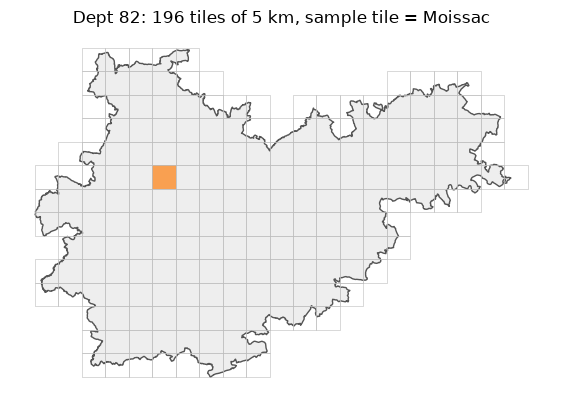

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
boundary.to_crs(CRS_L93).plot(ax=ax, color="#eeeeee", edgecolor="#555555")
grid.boundary.plot(ax=ax, color="#bbbbbb", linewidth=0.4)
gpd.GeoSeries([sample_tile_l93.geometry], crs=CRS_L93).plot(ax=ax, color="tab:orange", alpha=0.7)
ax.set_title(f"Dept {DEPT_CODE}: {len(grid)} tiles of {TILE_SIZE_M // 1000} km, sample tile = {SAMPLE_COMMUNE}")
ax.set_axis_off()
plt.show()

## STEP 5 — RPG API: Retrieve all data from a single tile (including Pagination)

In [9]:
def fetch_rpg_tile(session, geom, year, page_size=1000):
    pages, start = [], 0
    while True:
        params = {"annee": year, "geom": json.dumps(mapping(geom)), "_limit": page_size, "_start": start}
        data = get_json(session, RPG_API, params)
        pages.append(data)
        if len(data.get("features", [])) < page_size:
            return pages
        start += page_size


pages = fetch_rpg_tile(session, sample_tile, RPG_YEAR)
rpg_raw = pages[0]
features = [f for p in pages for f in p["features"]]

print("top-level keys:", [k for k in rpg_raw.keys() if k != "features"])
print("numberMatched (total count):", rpg_raw.get("numberMatched"), "| page count:", len(pages), "| received features:", len(features))
print("\nfirst feature properties:")
print(json.dumps(features[0]["properties"], indent=2, ensure_ascii=False))
print("geometry type:", features[0]["geometry"]["type"])

GET https://apicarto.ign.fr/api/rpg/v2?annee=2024&geom=%7B%22type%22%3A+%22Polygon%22%2C+%22coordinates%22%3A+%5B%5B%5B1.110...  ->  200, 423 KB
top-level keys: ['type', 'totalFeatures', 'numberMatched', 'numberReturned', 'timeStamp', 'crs']
numberMatched (total count): 543 | page count: 1 | received features: 543

first feature properties:
{
  "id_parcel": "3283205",
  "surf_parc": 0.01,
  "code_cultu": "BOR",
  "code_group": "28",
  "culture_d1": null,
  "culture_d2": null,
  "cat_cult_p": null
}
geometry type: MultiPolygon


In [10]:
# Get a rough sense of the volume: use this single tile to extrapolate to the entire department.
tile_kb = len(json.dumps({"features": features}).encode()) / 1024
n = len(features)
print(f"this tile: {n:,}, GeoJSON {tile_kb:,.0f} KB")
print(f"department-wide estimate (x {len(grid)} tiles): ~{n * len(grid):,}, ~{tile_kb * len(grid) / 1024:,.0f} MB")
print("Note: This is based on an orchard-dense tile, so edge tiles contain fewer parcels, so this is closer to an upper bound estimate. Parcels crossing tile boundaries will be duplicated.")

this tile: 543, GeoJSON 458 KB
department-wide estimate (x 196 tiles): ~106,428, ~88 MB
Note: This is based on an orchard-dense tile, so edge tiles contain fewer parcels, so this is closer to an upper bound estimate. Parcels crossing tile boundaries will be duplicated.


## STEP 6 — RPG GeoDataFrame

In [11]:
rpg = gpd.GeoDataFrame.from_features(features, crs=CRS_WGS84)

print("shape:", rpg.shape)
print("\ndtypes:\n", rpg.dtypes)
print("\nnull number:\n", rpg.isna().sum())
print("\nid_parcel duplicates:", rpg["id_parcel"].duplicated().sum())
display(rpg.drop(columns="geometry").head())

shape: (543, 8)

dtypes:
 geometry      geometry
id_parcel          str
surf_parc      float64
code_cultu         str
code_group         str
culture_d1      object
culture_d2      object
cat_cult_p         str
dtype: object

null number:
 geometry        0
id_parcel       0
surf_parc       0
code_cultu      0
code_group      0
culture_d1    543
culture_d2    543
cat_cult_p     30
dtype: int64

id_parcel duplicates: 0


,id_parcel,surf_parc,code_cultu,code_group,culture_d1,culture_d2,cat_cult_p
0,3283205,0.01,BOR,28,None,None,NaN
1,11484178,0.01,BOR,28,None,None,NaN
2,1748519,0.01,PPH,18,None,None,PP
3,11486426,0.01,SNE,28,None,None,NA
4,11483375,0.01,SNE,28,None,None,NA


In [12]:
# What types of crops are present: input for the next decision (defining the parcels that require pollination)
print("cat_cult_p (TA annual crops / CP permanent crops / PP permanent grassland / SB woodland):")
print(rpg["cat_cult_p"].value_counts(dropna=False))
print("\ncode_group:")
print(rpg["code_group"].value_counts().head(15))
print("\ncode_cultu top 15:")
print(rpg["code_cultu"].value_counts().head(15))

cat_cult_p (TA annual crops / CP permanent crops / PP permanent grassland / SB woodland):
cat_cult_p
CP     194
TA     172
PP     124
NaN     30
NA      23
Name: count, dtype: int64

code_group:
code_group
20    131
18    121
11     67
21     62
28     54
19     42
16     21
5      12
2       9
25      8
4       5
24      4
17      3
6       2
3       1
Name: count, dtype: int64

code_cultu top 15:
code_cultu
PPH    121
PRU     79
JAC     67
VRC     62
VRG     46
PTR     42
SNE     23
BOR     21
LUZ     17
CZH     12
BTA      9
MIS      9
MDI      7
CBT      5
AAR      4
Name: count, dtype: int64


## STEP 7 — Geometry validation

In [13]:
print("Invalid before fix:", (~rpg.is_valid).sum())
print("Geometry types (before):\n", rpg.geom_type.value_counts())

rpg["geometry"] = rpg.geometry.make_valid()

print("\nInvalid after fix:", (~rpg.is_valid).sum())
print("Geometry types (after):\n", rpg.geom_type.value_counts())

# make_valid can produce GeometryCollections → decide here whether a later step to extract polygons is needed

Invalid before fix: 5
Geometry types (before):
 MultiPolygon    543
Name: count, dtype: int64

Invalid after fix: 0
Geometry types (after):
 MultiPolygon          540
GeometryCollection      3
Name: count, dtype: int64


## STEP 8 — 면적 검증: 신고 면적(surf_parc) vs 계산 면적

In [14]:
rpg["area_ha_calc"] = rpg.to_crs(CRS_L93).area / 10_000
rpg["area_diff_pct"] = (rpg["area_ha_calc"] - rpg["surf_parc"]) / rpg["surf_parc"] * 100

print("surf_parc (ha) 분포:\n", rpg["surf_parc"].describe())
print("\n계산 면적과의 차이 (%):\n", rpg["area_diff_pct"].describe())
print("\n|차이| > 5% 필지 수:", (rpg["area_diff_pct"].abs() > 5).sum())

surf_parc (ha) 분포:
 count    543.000000
mean       1.532284
std        2.133305
min        0.010000
25%        0.250000
50%        0.740000
75%        1.810000
max       19.040000
Name: surf_parc, dtype: float64

계산 면적과의 차이 (%):
 count    543.000000
mean       0.045476
std        4.501130
min      -48.728822
25%       -0.272742
50%       -0.020148
75%        0.221612
max       49.694048
Name: area_diff_pct, dtype: float64

|차이| > 5% 필지 수: 32


## STEP 9 — 도 경계로 공간 필터링

In [15]:
before = len(rpg)
rpg_in = rpg[rpg.intersects(boundary.geometry.iloc[0])].copy()
print(f"필터 전 {before} -> 후 {len(rpg_in)} (제거 {before - len(rpg_in)})")

필터 전 543 -> 후 543 (제거 0)


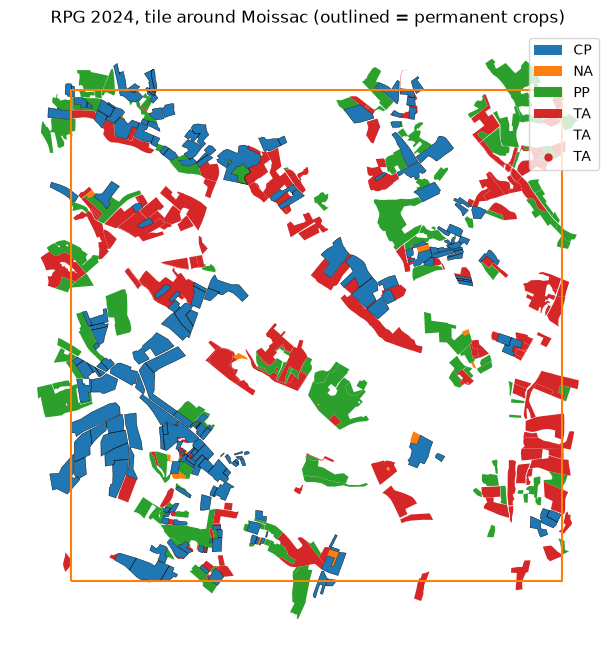

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
r93 = rpg_in.to_crs(CRS_L93)
r93.plot(ax=ax, column="cat_cult_p", categorical=True, legend=True, cmap="tab10", linewidth=0)
r93[r93["cat_cult_p"] == "CP"].boundary.plot(ax=ax, color="black", linewidth=0.3)
gpd.GeoSeries([sample_tile_l93.geometry], crs=CRS_L93).boundary.plot(ax=ax, color="tab:orange")
ax.set_title(f"RPG {RPG_YEAR}, tile around {SAMPLE_COMMUNE} (outlined = permanent crops)")
ax.set_axis_off()
plt.show()

## STEP 10 — 작은 샘플을 `data/samples/`에 저장

나중에 네트워크 없이 도는 단위 테스트의 fixture로 쓴다. 용량을 작게 유지해서 커밋한다.

In [17]:
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

communes_sample_path = SAMPLES_DIR / f"communes_{DEPT_CODE}_sample.geojson"
communes_sample = {"type": "FeatureCollection", "features": communes_raw["features"][:3]}
communes_sample_path.write_text(json.dumps(communes_sample, ensure_ascii=False), encoding="utf-8")

rpg_sample_path = SAMPLES_DIR / f"rpg_{DEPT_CODE}_{RPG_YEAR}_tile_sample.geojson"
rpg_sample = {k: v for k, v in rpg_raw.items() if k != "features"} | {"features": features[:50]}
rpg_sample_path.write_text(json.dumps(rpg_sample, ensure_ascii=False), encoding="utf-8")

for p in (communes_sample_path, rpg_sample_path):
    print(p.relative_to(ROOT), f"{p.stat().st_size / 1024:.0f} KB")

data\samples\communes_82_sample.geojson 25 KB
data\samples\rpg_82_2024_tile_sample.geojson 27 KB


## Observations

### Shape
- **Communes API**: 195 communes, GeoJSON FeatureCollection. Properties: `code` (INSEE, str), `nom` (str), `population` (int). 189 Polygon + 6 MultiPolygon. No nulls.
- **RPG API**: WFS-style FeatureCollection with `numberMatched` / `numberReturned`, so the total count is known before paging. Coordinates are lon/lat (EPSG:4326).
- **RPG properties**: `id_parcel` (str), `surf_parc` (ha, rounded to 0.01), `code_cultu` (3-letter crop code), `code_group` (crop group, str), `cat_cult_p` (TA / CP / PP / SB). Every geometry is MultiPolygon, even single-part parcels.
- **Keep**: `id_parcel`, `surf_parc`, `code_cultu`, `code_group`, `cat_cult_p`, `geometry`. **Drop**: `culture_d1`, `culture_d2` (100% null in this tile).
- **Two different "missing" values in `cat_cult_p`**: real null (30 rows, e.g. `BOR` field borders, `BTA` buffer strips) and the literal string `"NA"` (23 rows, e.g. `SNE` non-farmed surfaces). They mean different things and must stay separate. Parquet preserves this; a CSV round-trip with pandas defaults would silently turn `"NA"` into NaN.

### Volume
- Communes: 1.9 MB for the whole department with contours, in a single request.
- Tiles: 294 bbox tiles, of which 196 intersect the department (about 1/3 of requests saved).
- Sample tile (Moissac): 543 parcels, 1 page, ~460 KB GeoJSON.
- Naive extrapolation: ~106k parcels, ~88 MB GeoJSON, ~200 requests. This is a rough estimate, **not** an upper bound: one tile is not representative (this one includes Moissac town). Next step: profile 5 random tiles before the full run.
- Conclusion: the full ingest takes minutes and fits in laptop memory. No need for Spark at this stage.

### Quality
- **Boundary fidelity**: dissolved department area is 3,731 km², within ~1% of the official figure (~3,700 km²).
- **Invalid geometries**: 5/543 (0.9%). `make_valid()` fixes all of them but turns 3 into `GeometryCollection`. Polygon parts must be extracted after `make_valid()`, otherwise downstream area and overlay operations are unreliable.
- **Area check**: median difference between `surf_parc` and the Lambert-93 area is −0.02% (IQR ±0.27%), so declared and geometric areas agree. 32 parcels (5.9%) differ by more than 5%, up to ±49%.
  - Hypothesis: these are tiny parcels, where the 0.01 ha rounding of `surf_parc` dominates (0.01 ha error on a 0.02 ha parcel is 50%). To verify: compare the absolute difference in ha with `surf_parc`. Relative error is misleading when the denominator is small.
- **Slivers**: min 0.01 ha, median 0.74 ha. Group 28 (`BOR`, `BTA`, `SNE`) holds borders and non-farmed strips, not real fields.
- **Spatial filter**: removed 0 parcels, as expected for an interior tile. It only matters for edge tiles, so it must be tested on one.
- **Duplicates**: no duplicate `id_parcel` within a tile. Parcels crossing tile edges will appear in two tiles, so dedupe on `id_parcel` after merging.

### Proposed decisions (to confirm)
1. **Pollination target parcels**: `code_group == "20"` (orchards: apple, plum, cherry...; 131 parcels, 24% of this tile). Exclude 21 (vineyards, mostly self-pollinated) and 18/19 (grassland). Rapeseed (5) and sunflower (6) are bee *forage*, not pollination clients: useful later as landscape features, not for apiary placement. Check at department scale which group kiwi falls into.
2. **Minimum parcel size** for apiary placement: start with `surf_parc >= 0.5` ha, tune later.
3. **Ingest rules**: cache raw tile responses as-is; then dedupe on `id_parcel`, `make_valid()` + keep polygon parts, filter by department, and store as GeoParquet (keeps types and the null vs `"NA"` distinction).